In [1]:
import numpy as np # linear algebra
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
np.random.seed(0)
#from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.cluster import KMeans
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA

In [2]:
def score_dataset(X, y, model=RandomForestRegressor(random_state=1)):
    score = cross_val_score(model, X, y, cv=5, scoring="roc_auc")
    print(score.mean())

In [3]:
# Utility functions from Kaggle Tutorial(Feature engineering)
def make_mi_scores(X, y):
    X = X.copy()
    for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    # All discrete features should now have integer dtypes
    discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores


def plot_mi_scores(scores):
    scores = scores.sort_values(ascending=True)
    width = np.arange(len(scores))
    ticks = list(scores.index)
    plt.barh(width, scores)
    plt.yticks(width, ticks)
    plt.title("Mutual Information Scores")

In [4]:
def apply_pca(X, standardize=True):
    # Standardize
    if standardize:
        X = (X - X.mean(axis=0)) / X.std(axis=0)
    # Create principal components
    pca = PCA()
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings

In [5]:
rain_file_path = 'data/train.csv'
rain_data = pd.read_csv(rain_file_path)
test_file_path = "data/test.csv"
test_data = pd.read_csv(test_file_path)
X_test = test_data

In [6]:
X_test.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    1
windspeed        0
dtype: int64

In [7]:
display(rain_data)

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,2185,361,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,40.0,22.1,1
2186,2186,362,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,50.0,35.3,1
2187,2187,363,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,40.0,32.9,1
2188,2188,364,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,40.0,18.0,1


In [8]:
X = rain_data.drop(labels="rainfall", axis=1)
y = rain_data.rainfall

In [9]:
score_dataset(X, y)

0.8776175077070999


In [10]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.224609
sunshine         0.156949
humidity         0.133886
day              0.069490
id               0.069105
temparature      0.032819
windspeed        0.015840
dewpoint         0.015313
maxtemp          0.008077
pressure         0.002391
mintemp          0.001980
winddirection    0.000000
Name: MI Scores, dtype: float64

In [11]:
#cols = X.columns
cols = ["cloud", "sunshine", "humidity"]
cols_for_scaling = X.loc[:, cols]
cols_for_scaling

,cloud,sunshine,humidity
0,88.0,1.1,87.0
1,91.0,0.0,95.0
2,47.0,8.3,75.0
3,95.0,0.0,95.0
4,45.0,3.6,52.0
...,...,...,...
2185,88.0,0.1,97.0
2186,88.0,0.0,91.0
2187,79.0,5.0,79.0
2188,93.0,0.1,92.0


In [12]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

X_scaled = ms.fit_transform(cols_for_scaling)
X_scaled = pd.DataFrame(X_scaled, columns=[cols])
X_test_scaled = ms.fit_transform(cols_for_scaling)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=[cols])

X_scaled

,cloud,sunshine,humidity
0,0.877551,0.090909,0.813559
1,0.908163,0.000000,0.949153
2,0.459184,0.685950,0.610169
3,0.948980,0.000000,0.949153
4,0.438776,0.297521,0.220339
...,...,...,...
2185,0.877551,0.008264,0.983051
2186,0.877551,0.000000,0.881356
2187,0.785714,0.413223,0.677966
2188,0.928571,0.008264,0.898305


In [13]:
score_dataset(X_scaled, y)

0.8445816175829324


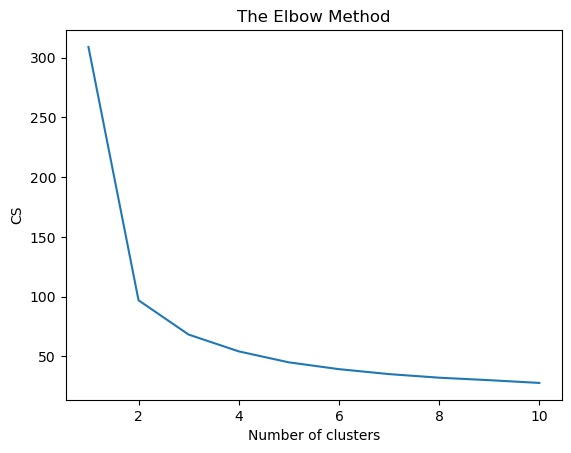

In [14]:
cs = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X_scaled)
    cs.append(kmeans.inertia_)
plt.plot(range(1, 11), cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [15]:
kmeans = KMeans(n_clusters=3, n_init = 10,random_state=0)
kmeans.fit(X_scaled)
labels = kmeans.labels_
# check how many of the samples were correctly labeled
correct_labels = sum(y == labels)
print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print('Accuracy score: {0:0.2f}'. format(correct_labels/float(y.size)))

Result: 1538 out of 2190 samples were correctly labeled.
Accuracy score: 0.70


In [16]:
#cluster = kmeans.fit(X_scaled)
X_scaled["cluster"] = kmeans.predict(X_scaled)


In [17]:
kmeans.fit(X_test_scaled)
X_test_scaled["cluster"] = kmeans.predict(X_test_scaled)

In [18]:
score_dataset(X_scaled, y)

0.8414333638977067


In [19]:
X_cd = kmeans.fit_transform(X_scaled)
X_cd = pd.DataFrame(X_cd, columns=[f"Centroid_{i}" for i in range(X_cd.shape[1])])
X_test_cd = kmeans.fit_transform(X_test_scaled)
X_test_cd = pd.DataFrame(X_test_cd, columns=[f"Centroid_{i}" for i in range(X_test_cd.shape[1])])

In [20]:
score_dataset(X_cd, y)

0.8403214393152647


In [21]:
X = X.join(X_cd)
X_test = X_test.join(X_test_cd)

In [22]:
score_dataset(X, y)

0.8791176616578346


In [23]:
X["cluster"] = X_scaled["cluster"]
X
X_test["cluster"] = X_test_scaled["cluster"]
X_test

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,Centroid_0,Centroid_1,Centroid_2,cluster
0,2190,1,1019.5,17.5,15.8,12.7,14.9,96.0,99.0,0.0,50.0,24.3,1.311429,0.033091,1.104977,1
1,2191,2,1016.5,17.5,16.5,15.8,15.1,97.0,99.0,0.0,50.0,35.3,1.399632,0.194146,1.170322,1
2,2192,3,1023.9,11.2,10.4,9.4,8.9,86.0,96.0,0.0,40.0,16.9,0.097855,1.242451,2.026074,0
3,2193,4,1022.9,20.6,17.3,15.2,9.5,75.0,45.0,7.1,20.0,50.6,1.414071,0.207997,1.177408,1
4,2194,5,1022.2,16.1,13.8,6.4,4.3,68.0,49.0,9.2,20.0,19.4,2.090921,1.240542,0.590005,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,2915,361,1020.8,18.2,17.6,16.1,13.7,96.0,95.0,0.0,20.0,34.3,1.373791,0.134489,1.152586,1
726,2916,362,1011.7,23.2,18.1,16.0,16.0,78.0,80.0,1.6,40.0,25.2,1.373791,0.134489,1.152586,1
727,2917,363,1022.7,21.0,18.5,17.0,15.5,92.0,96.0,0.0,50.0,21.9,1.346338,0.153401,1.133562,1
728,2918,364,1014.4,21.0,20.0,19.7,19.8,94.0,93.0,0.0,50.0,39.5,1.346223,0.142832,1.136173,1


In [24]:
score_dataset(X, y)

0.8746000003714862


In [25]:
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

cloud            0.214054
Centroid_1       0.203589
Centroid_0       0.190581
Centroid_2       0.187227
sunshine         0.186554
humidity         0.155204
cluster          0.147839
day              0.073101
id               0.066084
temparature      0.033889
maxtemp          0.023101
dewpoint         0.016881
mintemp          0.013290
windspeed        0.010776
pressure         0.006050
winddirection    0.005581
Name: MI Scores, dtype: float64

In [26]:
cor = X[X.columns].corrwith(y)
cor = cor.abs()
cor.sort_values(ascending=False)

cloud            0.641191
sunshine         0.555287
Centroid_1       0.547717
humidity         0.454213
Centroid_0       0.421527
Centroid_2       0.345541
cluster          0.340355
windspeed        0.111625
dewpoint         0.081965
maxtemp          0.079304
pressure         0.049886
temparature      0.049660
id               0.033674
mintemp          0.026841
winddirection    0.006939
day              0.000462
dtype: float64

In [27]:
X = X.drop(labels = ("day"), axis=1)
X_test = X_test.drop(labels = ("day"), axis=1)

In [28]:
score_dataset(X, y)

0.8786743556006259


In [29]:
X = X.drop(labels = ("winddirection"), axis=1)
X_test = X_test.drop(labels = ("winddirection"), axis=1)

In [30]:
score_dataset(X, y)

0.8769704565961265


In [31]:
X = X.drop(labels = ("id"), axis=1)
X_test = X_test.drop(labels = ("id"), axis=1)

In [32]:
score_dataset(X, y)

0.8743656835932223


In [33]:
cor = X[X.columns].corrwith(y)
cor = cor.abs()
cor.sort_values(ascending=False)

cloud          0.641191
sunshine       0.555287
Centroid_1     0.547717
humidity       0.454213
Centroid_0     0.421527
Centroid_2     0.345541
cluster        0.340355
windspeed      0.111625
dewpoint       0.081965
maxtemp        0.079304
pressure       0.049886
temparature    0.049660
mintemp        0.026841
dtype: float64

In [34]:
features = ["cloud", "sunshine", "Centroid_1", "humidity", "Centroid_0", "Centroid_2", "cluster", "windspeed"]
Z = X.loc[:, features]
W = X_test.loc[:, features]
# `apply_pca`, defined above, reproduces the code from the tutorial
pca, X_pca, loadings = apply_pca(Z)
print(loadings)

                 PC1       PC2       PC3       PC4       PC5       PC6  \
cloud      -0.438257 -0.197512 -0.043708  0.134729 -0.846027  0.177492   
sunshine    0.380704  0.370822 -0.004597 -0.314812 -0.465525 -0.567408   
Centroid_1  0.333618  0.459777  0.080220 -0.281055 -0.168917  0.726026   
humidity   -0.298207 -0.269498 -0.269502 -0.869235  0.097801  0.019578   
Centroid_0 -0.420774  0.348830  0.035389  0.029695  0.139719  0.180460   
Centroid_2  0.370508 -0.444183 -0.015455  0.006650 -0.047025  0.282691   
cluster    -0.372962  0.442937  0.030557 -0.006655  0.087355 -0.063771   
windspeed  -0.096641 -0.155828  0.957380 -0.217278 -0.007887 -0.050015   

                 PC7       PC8  
cloud      -0.038167  0.011621  
sunshine    0.282378 -0.004970  
Centroid_1 -0.185924 -0.040779  
humidity   -0.016885  0.002936  
Centroid_0  0.729886 -0.338101  
Centroid_2  0.589990  0.484695  
cluster    -0.055711  0.805560  
windspeed  -0.005238 -0.000639  


In [35]:
mi_scores = mutual_info_regression(X_pca, y)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X_pca.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores

PC1    0.187555
PC2    0.153215
PC8    0.099119
PC7    0.089025
PC5    0.050551
PC6    0.026108
PC3    0.014086
PC4    0.006553
Name: MI Scores, dtype: float64

In [36]:
score_dataset(X_pca, y)

0.8660444993369442


In [37]:
X = X.join(X_pca)
X

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,windspeed,Centroid_0,...,Centroid_2,cluster,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,17.2,1.311429,...,1.104977,1,-1.067451,-0.973521,-0.723227,0.157317,0.007419,-0.135945,0.037885,0.005061
1,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,21.9,1.399632,...,1.170322,1,-1.527121,-1.326208,-0.522898,-0.800075,0.068287,0.341515,0.042144,0.002148
2,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,18.1,0.097855,...,2.026074,0,3.922981,-0.435524,-0.091863,-0.140639,-0.026920,0.136681,-0.195696,0.031401
3,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,35.6,1.414071,...,1.177408,1,-1.755119,-1.570493,0.795221,-1.077480,-0.131975,0.338484,0.046248,0.000378
4,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,24.8,2.090921,...,0.590005,2,0.804596,3.439658,1.613913,2.731256,1.235054,0.474400,0.322781,0.283790
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2185,1014.6,23.2,20.6,19.1,19.9,97.0,88.0,0.1,22.1,1.393924,...,1.170377,1,-1.504452,-1.340013,-0.562577,-1.070158,0.212944,0.328202,0.037351,0.002436
2186,1012.4,17.2,17.3,16.3,15.3,91.0,88.0,0.0,35.3,1.373791,...,1.152586,1,-1.462679,-1.419924,0.908451,-0.640603,0.162717,0.135855,0.021855,0.002613
2187,1013.3,19.0,16.3,14.3,12.6,79.0,79.0,5.0,32.9,2.065460,...,0.120853,2,-1.376491,2.327309,1.363288,-0.231999,-0.118727,0.134890,-0.136171,-0.041182
2188,1022.3,16.4,15.2,13.8,14.7,92.0,93.0,0.1,18.0,1.390205,...,1.159755,1,-1.436175,-1.203178,-0.807421,-0.354497,-0.062270,0.298188,0.045451,0.002037


In [38]:
pca, X_pca, loadings = apply_pca(Z)
X_test = X_test.join(X_pca)

In [39]:
score_dataset(X, y)

0.87522204032077


In [40]:
X_test.isnull().sum()

pressure       0
maxtemp        0
temparature    0
mintemp        0
dewpoint       0
humidity       0
cloud          0
sunshine       0
windspeed      0
Centroid_0     0
Centroid_1     0
Centroid_2     0
cluster        0
PC1            0
PC2            0
PC3            0
PC4            0
PC5            0
PC6            0
PC7            0
PC8            0
dtype: int64

In [41]:
model=RandomForestRegressor(random_state=1)
model.fit(X, y)
rf_test_preds = model.predict(X_test)

In [42]:
X_test["id"] = test_data["id"]

In [43]:
X_test["rainfall"] = rf_test_preds

In [44]:
X_test.to_csv('submission.csv', columns=['id','rainfall'], index=False)